# pytorch-diffusion 原理详解

这份笔记按照当前仓库的实现思路，拆解 diffusion 的核心流程，并给出一个尽量精简、但保留关键机制的最小实现。

本项目本质上是 **条件 DDPM**：
- 在像素空间直接对图像加噪和去噪
- 网络学习预测噪声，而不是直接预测干净图像
- 条件信息不是文本，而是数字类别 `0~9`
- 通过时间步 embedding 和类别 embedding 共同指导去噪

对应代码文件：
- `diffusion.py`：前向扩散参数与加噪公式
- `train.py`：训练流程，目标是预测真实噪声
- `denoise.py`：反向采样，从纯噪声一步步还原图像
- `unet.py`：噪声预测网络
- `conv_block.py`、`cross_attn.py`、`time_position_emb.py`：条件注入细节

它和严格意义上的 Stable Diffusion 不同：这里没有 VAE latent、没有文本编码器、也不是 latent diffusion。

## 1. 前向扩散：如何把原图一步变成第 t 步噪声图

在 DDPM 里，原图记为 $x_0$。随着时间步增加，我们不断往图像里加入高斯噪声，直到它逐渐接近纯噪声。

仓库在 `diffusion.py` 中先定义：

$$
\beta_t \in [0.0001, 0.02]
$$

$$
\alpha_t = 1 - \beta_t
$$

$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$

这样可以直接写出第 $t$ 步图像的闭式表达：

$$
x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
$$

这正是仓库 `forward_diffusion` 的核心。它不是一步步循环加噪，而是直接从 $x_0$ 采样出任意一步的 $x_t$。这使训练更高效。

直观理解：
- 当 $t$ 很小时，$\bar{\alpha}_t$ 仍然较大，图像保留较多原始结构
- 当 $t$ 很大时，$1-\bar{\alpha}_t$ 更大，图像会越来越像纯随机噪声
- 训练时随机采样不同的 $t$，让模型学会在任意噪声强度下都能识别噪声

In [7]:
import math
import torch
from torch import nn

IMG_SIZE = 48
T = 1000
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. 噪声日程 beta_t：决定每一步往图像里加多少噪声。
# 这里和仓库 diffusion.py 一样，使用从小到大的线性日程。
betas = torch.linspace(0.0001, 0.02, T, device=DEVICE)

# 2. alpha_t = 1 - beta_t。
# 它表示当前这一步保留多少原图信息。
alphas = 1.0 - betas

# 3. alpha_bar_t = prod(alpha_1 ... alpha_t)。
# 它表示从第 0 步走到第 t 步以后，原图整体还保留了多少比例。
alphas_cumprod = torch.cumprod(alphas, dim=0)

# 4. 前一个时刻的累计 alpha_bar_{t-1}。
# 反向采样的后验方差会用到它。
alphas_cumprod_prev = torch.cat(
    [torch.ones(1, device=DEVICE), alphas_cumprod[:-1]],
    dim=0,
)

# 5. DDPM 反向采样时使用的后验方差。
# 这个量对应仓库 denoise.py 里的 variance。
variance = (1 - alphas) * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)

print('betas:', betas.shape)
print('alphas_cumprod:', alphas_cumprod.shape)
print('variance:', variance.shape)

betas: torch.Size([1000])
alphas_cumprod: torch.Size([1000])
variance: torch.Size([1000])


In [8]:
def forward_diffusion(x0, t):
    """
    根据闭式公式，直接从 x0 采样出任意时刻 xt。

    参数
    x0: (batch, channel, height, width)
        干净图像，建议像仓库训练那样先缩放到 [-1, 1]。
    t: (batch,)
        每张图对应一个时间步，因此一个 batch 里不同图可以处于不同噪声强度。

    返回
    xt: 与 x0 同形状的带噪图
    noise: 本次实际加入的高斯噪声，训练时它就是监督信号
    """
    # 生成和输入图像同形状的标准高斯噪声 epsilon。
    noise = torch.randn_like(x0)

    # 取出每张图对应时间步的 alpha_bar_t，并 reshape 成 (batch,1,1,1)，
    # 这样就可以通过广播作用到整张图。
    alpha_bar_t = alphas_cumprod[t].view(x0.size(0), 1, 1, 1)

    # DDPM 前向扩散闭式公式：
    # xt = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * epsilon
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
    return xt, noise

# 最小示例：同一个 batch 中，让两张图处于不同的时间步。
x0 = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE).clamp(-1, 1)
t = torch.tensor([10, 700], dtype=torch.long, device=DEVICE)
xt, noise = forward_diffusion(x0, t)

print('x0:', x0.shape)
print('t:', t.tolist())
print('xt:', xt.shape)
print('noise:', noise.shape)

x0: torch.Size([2, 1, 48, 48])
t: [10, 700]
xt: torch.Size([2, 1, 48, 48])
noise: torch.Size([2, 1, 48, 48])


## 2. 为什么训练目标是“预测噪声”

仓库 `train.py` 的训练目标不是直接还原 $x_0$，而是让模型预测加入的真实噪声 $\epsilon$。

设模型为 $\epsilon_\theta(x_t, t, c)$，其中：
- $x_t$：第 $t$ 步带噪图
- $t$：时间步
- $c$：类别条件，这里是数字标签

训练时先生成：

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
$$

然后把 $(x_t, t, c)$ 输入模型，让模型去预测这份 $\epsilon$。

损失可以写成：

$$
L = \|\epsilon_\theta(x_t, t, c) - \epsilon\|
$$

仓库里使用的是 `L1Loss`。很多论文里也会用 MSE，本质上都是在学“如何从带噪图中识别噪声”。

这样做的好处是：
- 目标稳定，噪声分布固定为标准高斯
- 不同时间步可以统一成一个预测任务
- 反向采样时，只要能估计噪声，就能推回上一时刻的图像

## 3. 本项目的条件注入：时间步 + 类别 + UNet 主干

仓库的 `UNet` 做了两种条件注入：时间步 embedding 和类别 embedding。它们共同决定模型在当前噪声强度下应该“朝哪个目标去噪”。

### 3.1 时间步 embedding

`time_position_emb.py` 中使用的是正弦位置编码。时间步 $t$ 会被映射成一个向量，然后在 `conv_block.py` 中通过线性层投影到当前特征图通道数，再加到特征图上。

这一步的作用是告诉网络：当前输入图像的噪声到底有多重。没有这个条件，模型就不知道自己是在处理“几乎干净的图”，还是“几乎纯噪声的图”。

### 3.2 类别 embedding

`unet.py` 中有一个 `nn.Embedding(10, cls_emb_size)`，把数字类别 `0~9` 变成向量。随后每个卷积块都会调用 `cross_attn.py`，让类别信息参与图像特征变换。

从设计意图上看，这是在做条件引导：
- 图像特征作为 Query
- 类别向量作为 Key/Value
- 让模型生成符合指定数字类别的图像

这个仓库中的 cross attention 只有一个 Key/Value，因此它比文本条件 diffusion 里的多 token cross attention 要简单很多，但依然能够把类别信息注入进去。

### 3.3 UNet 为什么适合 diffusion

UNet 的核心是：
- 编码器逐步下采样，扩大感受野，提取更抽象的全局语义
- 解码器逐步上采样，把抽象特征还原到高分辨率
- skip connection 把浅层的局部细节直接传给解码器，避免细节在下采样过程中丢失

在 diffusion 中，输入和输出的空间尺寸通常相同，因为模型输入是 $x_t$，输出是同尺寸的噪声预测 $\epsilon_\theta(x_t, t, c)$。这和语义分割里的 UNet 很像：都需要像素级对齐。

### 3.4 维度如何变化

下面给一个 48x48 输入时的典型例子，使用 3 次下采样：

- 输入：`(B, 1, 48, 48)`
- 编码块 1 后：`(B, 64, 48, 48)`，池化后变成 `24x24`
- 编码块 2 后：`(B, 128, 24, 24)`，池化后变成 `12x12`
- 编码块 3 后：`(B, 256, 12, 12)`，池化后变成 `6x6`
- bottleneck：`(B, 512, 6, 6)`
- 上采样回 `12x12`，与编码器对应层拼接
- 再上采样回 `24x24`，继续拼接
- 最后上采样回 `48x48`，输出 `(B, 1, 48, 48)`

### 3.5 crop 为什么会出现

最原始的 UNet 常用 `valid convolution`，也就是不加 padding。这样每做一次 3x3 卷积，特征图宽高都会缩小 2，因此解码器上采样后的特征图，尺寸往往和编码器保存的 skip feature 对不上，这时就需要对 skip feature 做中心裁剪，也就是 crop。

本仓库里的卷积基本使用了 `padding=1`，因此卷积本身不改变空间尺寸，很多时候就不需要 crop。

但在更通用的实现里，仍然建议保留一个 `center_crop` 函数，原因有两个：
- 输入尺寸不一定总能被 $2^n$ 整除
- 上采样和卷积实现细节可能让 skip 和 decoder 特征出现 1 到 2 个像素的差异

下面的示例代码会实现一个更完整的条件 UNet，同时保留 crop 逻辑，便于把原理看透。

In [ ]:
class TimePositionEmbedding(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        # 只构造一半频率，另一半由 sin/cos 共同组成。
        half = emb_size // 2
        freq = torch.exp(torch.arange(half) * (-math.log(10000) / max(half - 1, 1)))
        self.register_buffer('freq', freq)

    def forward(self, t):
        # t: (batch,) -> (batch, 1)
        t = t.view(-1, 1).float()

        # 每个时间步乘以一组不同频率，得到 phase。
        phase = t * self.freq.unsqueeze(0)

        # 输出形状: (batch, emb_size)
        return torch.cat([phase.sin(), phase.cos()], dim=-1)

class SimpleCrossAttention(nn.Module):
    def __init__(self, channel, qsize=32, vsize=32, fsize=64, cls_emb_size=32):
        super().__init__()
        self.w_q = nn.Linear(channel, qsize)
        self.w_k = nn.Linear(cls_emb_size, qsize)
        self.w_v = nn.Linear(cls_emb_size, vsize)
        self.softmax = nn.Softmax(dim=-1)
        self.proj = nn.Linear(vsize, channel)
        self.norm1 = nn.LayerNorm(channel)
        self.ff = nn.Sequential(
            nn.Linear(channel, fsize),
            nn.ReLU(),
            nn.Linear(fsize, channel),
        )
        self.norm2 = nn.LayerNorm(channel)

    def forward(self, x, cls_emb):
        # 这个x在
        # x: (B, C, H, W) -> (B, H, W, C)
        x_hw = x.permute(0, 2, 3, 1)

        # 1. 每个像素位置都产生一个 query。
        q = self.w_q(x_hw).view(x.size(0), x.size(2) * x.size(3), -1)
        # 形状：(B,H*W,C)

        # 2. 类别向量产生一个 key 和一个 value。
        #    这个实现只有一个 key/value，因此注意力会退化成非常简单的形式。
        k = self.w_k(cls_emb).unsqueeze(-1)
        v = self.w_v(cls_emb).unsqueeze(1)
        # 形状：

        # 3. 计算注意力分数，输出形状为 (B, H*W, 1)。
        attn = torch.matmul(q, k) / math.sqrt(q.size(-1))
        attn = self.softmax(attn)

        # 4. 把类别 value 广播到各个像素位置。
        z = torch.matmul(attn, v)
        z = self.proj(z).view(x.size(0), x.size(2), x.size(3), x.size(1))

        # 5. 残差 + 前馈，保持输出形状不变。
        z = self.norm1(z + x_hw)
        out = self.norm2(self.ff(z) + z)
        return out.permute(0, 3, 1, 2)

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, cls_dim):
        super().__init__()
        # 第一次卷积：把通道数从 in_channels 变成 out_channels。
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

        # 时间步 embedding 会被投影到当前层通道数，然后加到整张特征图上。
        self.time_proj = nn.Linear(time_dim, out_channels)

        # 第二次卷积：保持空间尺寸不变，继续提取局部结构。
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

        # 类别条件在卷积后通过简化版 cross attention 融入。
        self.cross_attn = SimpleCrossAttention(
            channel=out_channels,
            qsize=32,
            vsize=32,
            fsize=64,
            cls_emb_size=cls_dim,
        )
        self.act = nn.ReLU()

    def forward(self, x, t_emb, cls_emb):
        # x: (B, Cin, H, W) -> (B, Cout, H, W)
        x = self.conv1(x)

        # t_emb: (B, time_dim) -> (B, Cout, 1, 1)，然后广播到整张特征图。
        t_bias = self.act(self.time_proj(t_emb)).view(x.size(0), x.size(1), 1, 1)

        # 把时间条件加到每个空间位置。
        x = self.conv2(x + t_bias)

        # 输出仍是 (B, Cout, H, W)。
        return self.cross_attn(x, cls_emb)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, cls_dim):
        super().__init__()
        self.block = ConvBlock(in_channels, out_channels, time_dim, cls_dim)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x, t_emb, cls_emb):
        # skip 用于之后 decoder 拼接。
        skip = self.block(x, t_emb, cls_emb)

        # down 后空间尺寸减半。
        down = self.pool(skip)
        return skip, down

def center_crop(skip, target_hw):
    """
    当 skip feature 的空间尺寸比目标大时，执行中心裁剪。
    这在原始 U-Net 或非整齐输入尺寸场景中很常见。
    """
    target_h, target_w = target_hw
    _, _, h, w = skip.shape

    if h == target_h and w == target_w:
        return skip

    top = (h - target_h) // 2
    left = (w - target_w) // 2
    # 返回裁剪后的 skip，形状为 (B, C, target_h, target_w)。
    # 相当于只要 skip 中心的 target_h x target_w 区域。
    return skip[:, :, top:top + target_h, left:left + target_w]

class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, time_dim, cls_dim):
        super().__init__()
        # 转置卷积把空间尺寸放大 2 倍。
        # 在输入的每个元素之间插入 stride−1stride−1 个零，然后再padding,最后做普通卷积（stride=1,padding=0）。
        # 公式：H_out = (H_in - 1) * stride - 2*padding + kernel_size + output_padding
        # 这里 kernel_size=2, stride=2, padding=0, output_padding=0，所以 H_out = (H_in - 1) * 2 + 2 =2 * H_in。
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        # 拼接后通道数会变成 out_channels + skip_channels。
        self.block = ConvBlock(out_channels + skip_channels, out_channels, time_dim, cls_dim)

    def forward(self, x, skip, t_emb, cls_emb):
        # x: (B, Cin, H, W) -> (B, Cout, 2H, 2W)
        x = self.up(x)

        # 如果尺寸不完全对齐，先把 skip 做中心裁剪。
        skip = center_crop(skip, (x.size(2), x.size(3)))

        # 在通道维拼接 encoder 和 decoder 的特征。
        x = torch.cat([skip, x], dim=1)

        # 经过卷积块后，通道降到 out_channels。
        return self.block(x, t_emb, cls_emb)


input xt: torch.Size([2, 1, 48, 48])
time emb: torch.Size([2, 128])
class emb: torch.Size([2, 32])
after down1 skip: torch.Size([2, 64, 48, 48]) down: torch.Size([2, 64, 24, 24])
after down2 skip: torch.Size([2, 128, 24, 24]) down: torch.Size([2, 128, 12, 12])
after down3 skip: torch.Size([2, 256, 12, 12]) down: torch.Size([2, 256, 6, 6])
bottleneck: torch.Size([2, 512, 6, 6])
after up3: torch.Size([2, 256, 12, 12])
after up2: torch.Size([2, 128, 24, 24])
after up1: torch.Size([2, 64, 48, 48])
output: torch.Size([2, 1, 48, 48])
parameter count: 8194529
demo output shape: torch.Size([2, 1, 48, 48])


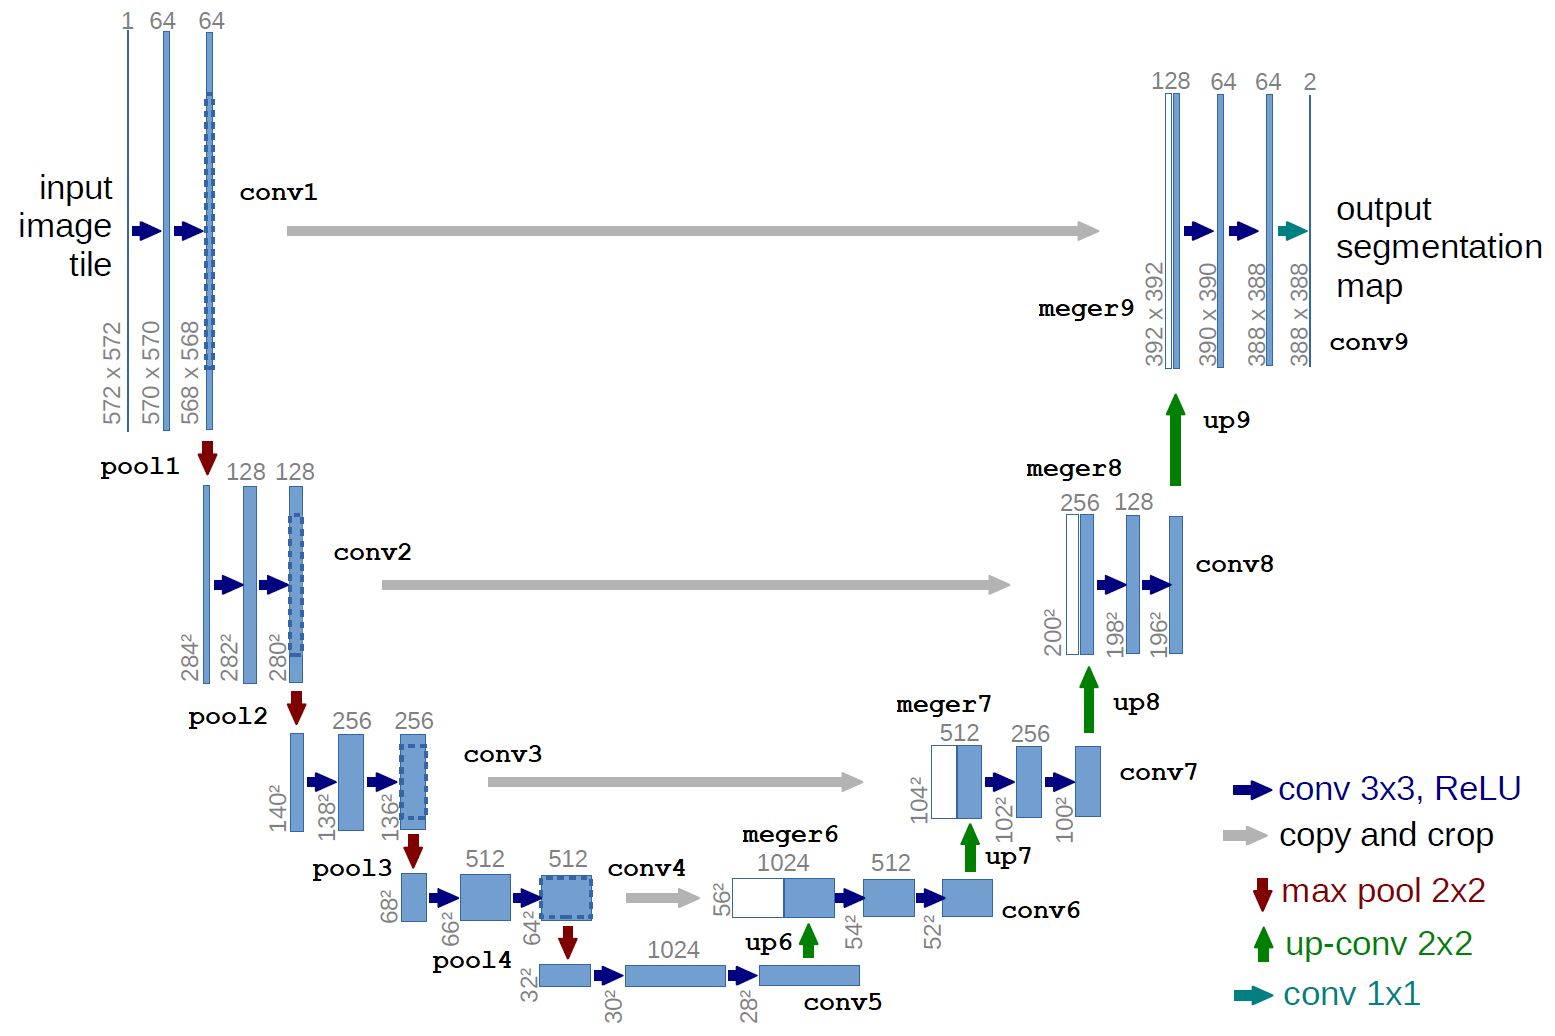

In [ ]:
class ConditionalUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=(64, 128, 256), bottleneck_channels=512, time_dim=128, num_classes=10, cls_dim=32):
        super().__init__()

        # 时间条件：t -> sinusoidal embedding -> MLP
        self.time_emb = nn.Sequential(
            TimePositionEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU(),
        )

        # 类别条件：数字类别 -> embedding 向量
        self.cls_emb = nn.Embedding(num_classes, cls_dim)

        c1, c2, c3 = base_channels

        # Encoder: 48 -> 24 -> 12 -> 6
        self.down1 = DownBlock(in_channels, c1, time_dim, cls_dim)
        self.down2 = DownBlock(c1, c2, time_dim, cls_dim)
        self.down3 = DownBlock(c2, c3, time_dim, cls_dim)

        # Bottleneck: 保持 6x6，扩大语义表达能力
        self.bottleneck = ConvBlock(c3, bottleneck_channels, time_dim, cls_dim)

        # Decoder: 6 -> 12 -> 24 -> 48
        self.up3 = UpBlock(bottleneck_channels, c3, c3, time_dim, cls_dim)
        self.up2 = UpBlock(c3, c2, c2, time_dim, cls_dim)
        self.up1 = UpBlock(c2, c1, c1, time_dim, cls_dim)

        # 输出层：把通道还原成和输入相同的 1 通道噪声图。
        self.out = nn.Conv2d(c1, in_channels, kernel_size=1)

    def forward(self, xt, t, cls, verbose=False):
        # 条件编码。
        t_emb = self.time_emb(t)
        cls_emb = self.cls_emb(cls)

        if verbose:
            print('input xt:', xt.shape)
            print('time emb:', t_emb.shape)
            print('class emb:', cls_emb.shape)

        # Encoder
        skip1, x = self.down1(xt, t_emb, cls_emb)
        if verbose:
            print('after down1 skip:', skip1.shape, 'down:', x.shape)

        skip2, x = self.down2(x, t_emb, cls_emb)
        if verbose:
            print('after down2 skip:', skip2.shape, 'down:', x.shape)

        skip3, x = self.down3(x, t_emb, cls_emb)
        if verbose:
            print('after down3 skip:', skip3.shape, 'down:', x.shape)

        # Bottleneck
        x = self.bottleneck(x, t_emb, cls_emb)
        if verbose:
            print('bottleneck:', x.shape)

        # Decoder
        x = self.up3(x, skip3, t_emb, cls_emb)
        if verbose:
            print('after up3:', x.shape)

        x = self.up2(x, skip2, t_emb, cls_emb)
        if verbose:
            print('after up2:', x.shape)

        x = self.up1(x, skip1, t_emb, cls_emb)
        if verbose:
            print('after up1:', x.shape)

        out = self.out(x)
        if verbose:
            print('output:', out.shape)

        # 输出和输入 xt 同尺寸，表示预测的噪声。
        return out


In [ ]:
model = ConditionalUNet().to(DEVICE)

# 用一个最小 batch 验证维度变化。
demo_xt = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
demo_t = torch.tensor([10, 700], dtype=torch.long, device=DEVICE)
demo_cls = torch.tensor([3, 8], dtype=torch.long, device=DEVICE)
demo_out = model(demo_xt, demo_t, demo_cls, verbose=True)

print('parameter count:', sum(p.numel() for p in model.parameters()))
print('demo output shape:', demo_out.shape)

## 4. 最小训练步骤：和 `train.py` 一一对应

仓库的训练循环可以压缩成下面几步：

1. 读入原图 $x_0$ 和类别标签 $c$
2. 把像素从 `[0, 1]` 映射到 `[-1, 1]`
3. 为每张图随机采样时间步 $t$
4. 用前向扩散公式得到 $x_t$ 和真实噪声 $\epsilon$
5. 用模型预测 $\epsilon_\theta(x_t, t, c)$
6. 计算预测噪声与真实噪声之间的损失
7. 反向传播更新参数

这就是 diffusion 训练最核心的闭环：
- 前向扩散负责制造训练样本
- 模型负责预测噪声
- 损失函数负责把预测拉向真实噪声

由于每次训练都会随机采样不同的 $t$，模型最终学会在不同噪声强度下都能工作。

In [10]:
# 优化器负责更新模型参数。
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 仓库 train.py 使用的是 L1Loss。
loss_fn = nn.L1Loss()

# 这里用随机张量模拟一个 batch。
# 在真实训练中，x0 来自 MNIST，并且会先从 [0, 1] 映射到 [-1, 1]。
batch_size = 8
x0 = torch.randn(batch_size, 1, IMG_SIZE, IMG_SIZE, device=DEVICE).clamp(-1, 1)

# 每张图配一个类别条件。
cls = torch.randint(0, 10, (batch_size,), device=DEVICE)

# 每张图随机采一个时间步。
# 这一步很关键，因为模型必须学会在任意噪声强度下都能预测噪声。
t = torch.randint(0, T, (batch_size,), device=DEVICE)

# 先把干净图像变成第 t 步的带噪图，同时保留真实噪声作为监督信号。
xt, true_noise = forward_diffusion(x0, t)

# 输入 (xt, t, cls)，输出与 xt 同尺寸的噪声预测。
pred_noise = model(xt, t, cls)

# 训练目标：让预测噪声尽量接近真实噪声。
loss = loss_fn(pred_noise, true_noise)

# 标准反向传播流程。
optimizer.zero_grad()
loss.backward()
optimizer.step()

print('x0:', x0.shape)
print('xt:', xt.shape)
print('pred_noise:', pred_noise.shape)
print('train loss:', float(loss.detach()))

x0: torch.Size([8, 1, 48, 48])
xt: torch.Size([8, 1, 48, 48])
pred_noise: torch.Size([8, 1, 48, 48])
train loss: 0.813339352607727


## 5. 反向扩散：为什么能从纯噪声还原出图像

训练好以后，模型已经学会在任意时间步 $t$ 下估计噪声 $\epsilon_\theta(x_t, t, c)$。这时就可以反过来做采样。

DDPM 的一步反推均值写成：

$$
\mu_t = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t, t, c)\right)
$$

然后采样：

$$
x_{t-1} = \mu_t + \sqrt{\sigma_t^2} z, \quad z \sim \mathcal{N}(0, I)
$$

其中最后一步 $t=0$ 通常不再加随机噪声。

把这个过程和 UNet 联系起来看，会更清楚：
- 当前输入 `x_t` 的空间尺寸是 `(B, 1, 48, 48)`
- UNet 内部先下采样提取全局结构，再上采样恢复细节
- 输出仍然是 `(B, 1, 48, 48)`，因为它预测的是“每个像素位置上的噪声”
- 有了这张噪声图，就能用上面的公式估计上一时刻的图像

仓库 `denoise.py` 的 `backward_denoise` 就是在做这件事：
- 从纯高斯噪声开始
- 从 `T-1` 一直循环到 `0`
- 每一步都调用模型预测噪声
- 用公式求出上一时刻图像
- 最终得到接近真实分布的样本

所以 diffusion 生成不是一次性“画出”图像，而是反复执行“估计噪声 -> 去掉一部分噪声”的过程。

In [11]:
@torch.no_grad()
def backward_denoise(model, xt, cls):
    """
    从当前噪声图 xt 出发，一步步反推到 x0。

    参数
    model: 已训练好的噪声预测网络
    xt:    当前时刻图像，通常一开始取纯高斯噪声
    cls:   条件类别

    返回
    最终生成的样本，形状与 xt 相同
    """
    model.eval()

    # 从大时间步往小时间步走，逐步去噪。
    for step in range(T - 1, -1, -1):
        # 当前整个 batch 共享同一个 step。
        t = torch.full((xt.size(0),), step, dtype=torch.long, device=xt.device)

        # 1. 先让模型预测当前 xt 中含有的噪声。
        pred_noise = model(xt, t, cls)

        # 2. 取出当前 step 对应的扩散参数，并 reshape 成可广播形状。
        shape = (xt.size(0), 1, 1, 1)
        alpha_t = alphas[t].view(*shape)
        alpha_bar_t = alphas_cumprod[t].view(*shape)
        var_t = variance[t].view(*shape)

        # 3. 根据 DDPM 公式计算 x_{t-1} 的均值。
        mean = (xt - (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t) * pred_noise) / torch.sqrt(alpha_t)

        # 4. 如果还没到最后一步，就在均值上再采一份随机噪声。
        #    这一步使生成过程保持随机性，而不是完全确定性。
        if step > 0:
            xt = mean + torch.sqrt(var_t) * torch.randn_like(xt)
        else:
            xt = mean

        # 5. 为了稳定演示，把像素裁到 [-1, 1]。
        xt = xt.clamp(-1, 1)

    return xt

# 从纯噪声开始，根据类别条件生成。
start_noise = torch.randn(4, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
cls = torch.tensor([0, 1, 2, 3], dtype=torch.long, device=DEVICE)
samples = backward_denoise(model, start_noise, cls)

print('start noise:', start_noise.shape)
print('generated samples:', samples.shape)

start noise: torch.Size([4, 1, 48, 48])
generated samples: torch.Size([4, 1, 48, 48])
